In [27]:
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, START, END

from IPython.display import display, Image
from pydantic import BaseModel, Field

In [28]:
llm = ChatOllama(
    model="mistral:7b",
    temperature=0.3
)

In [29]:
# defining the graph schema using pydantic models.
class graph_schema(BaseModel):
   topic: str = Field(..., description="The topic for the post.")
   post: str = Field("", description="The content of the post.")
   curated_post: str = Field("", description="The curated version of the post.") 

In [30]:
# creating create post node.
def create_post_node(state: graph_schema) -> graph_schema:
    # topic = state.topic => getting the topic from the pydantic state and this state is not a dict but a pydantic model.
    state = state.model_dump() # converting the pydantic model to a dict to pass it to the llm.
    topic = state["topic"]
    
    post = llm.invoke(f"Create a post for the linkedin topic: {topic}").content
    
    state["post"] = post
    
    return state
    

In [31]:
# defining function for curating the post.
def curate_post_node(state: graph_schema) -> graph_schema:
    state = state.model_dump() # converting the pydantic model to a dict to pass it to the llm.
    post = state["post"]
    
    curated_post = llm.invoke(f"Curate the following post for linkedin: {post}").content
    
    state["curated_post"] = curated_post
    
    return state

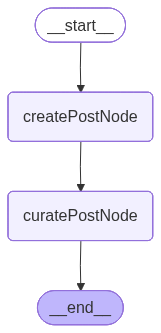

In [32]:
# defining the graph 
graph = StateGraph(graph_schema)

# creating the nodes for the graph.
graph.add_node("createPostNode", create_post_node)
graph.add_node("curatePostNode", curate_post_node)

# creating the edges for the graph.
graph.add_edge(START, "createPostNode")
graph.add_edge("createPostNode", "curatePostNode")
graph.add_edge("curatePostNode", END)

# let's compile the graph and visualize it.
compiled_graph = graph.compile()
Image(compiled_graph.get_graph().draw_mermaid_png())

In [33]:
if __name__ == "__main__":
    init_state = {
        "topic": "What is GenAI?"
    }
    
    final_res = compiled_graph.invoke(init_state)
    print(final_res["curated_post"])

 Title: Unveiling the Enigma of GenAI: The Future of Artificial Intelligence

Greetings LinkedIn Community,

I am excited to embark on a captivating journey into the realm of GenAI, a topic that has been creating quite a stir in the tech sphere.

GenAI, or General Artificial Intelligence, signifies the next leap in AI evolution. Unlike the limited AI systems we interact with daily, such as Siri, Alexa, and autonomous vehicles, GenAI systems are engineered to execute any intellectual task a human being can.

Imagine a system capable of not only comprehending and responding to intricate queries but also drafting articles, composing music, designing architectural masterpieces, or even diagnosing diseases. This is the vision of GenAI.

However, it's essential to acknowledge that we are merely scratching the surface of GenAI development. Although remarkable advancements have been made in domains like machine learning and deep learning, the creation of a truly general AI system that mirrors 